# Projet de Scoring de Crédit : Évaluation de la Solvabilité Client

Ce notebook présente la démarche complète de développement de modèles prédictifs de classification supervisée pour évaluer si un demandeur de crédit est **solvable (1)** ou **non solvable (0)** à partir de ses données financières.

Le projet respecte une architecture modulaire et les principes du patron de conception **MVC (Modèle-Vue-Contrôleur)**.

---

## 1. Importation des Bibliothèques et Configuration

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

## 2. Chargement et Exploration du Jeu de Données

Le jeu de données utilisé provient du dépôt **UCI Machine Learning Repository** (German Credit Dataset) adapté avec des variables cohérentes en français.

Afin de garantir que ce notebook fonctionne dans n'importe quel environnement (Windows local, WSL Linux ou Google Colab), nous implémentons un chargeur robuste. Si le fichier CSV local n'est pas trouvé, le notebook le télécharge et le reconstruit automatiquement depuis l'UCI.

In [ ]:
# Liste des chemins possibles selon l'environnement de montage (Windows ou Linux WSL)
possible_paths = [
    'credit_data.csv',
    '../credit_data.csv',
    '/mnt/c/Users/HP ELITEBOOK/Projet1/credit_data.csv',
    'C:/Users/HP ELITEBOOK/Projet1/credit_data.csv',
    '/c/Users/HP ELITEBOOK/Projet1/credit_data.csv'
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path:
    print(f"Chargement des données existantes depuis : {data_path}")
    df = pd.read_csv(data_path)
else:
    print("Fichier local non trouvé. Téléchargement et reconstruction automatique depuis l'UCI...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    df_raw = pd.read_csv(url, sep='\\s+', header=None)
    
    # Mappages du jeu de données
    history_map = {
        'A30': 'Bon', 'A31': 'Bon', 'A32': 'Moyen',
        'A33': 'Mauvais', 'A34': 'Mauvais'
    }
    historique_paiement = df_raw[2].map(history_map)
    
    job_map = {
        'A171': 'Sans emploi', 'A172': 'CDD',
        'A173': 'CDI', 'A174': 'Freelance'
    }
    type_contrat = df_raw[16].map(job_map)
    dettes = df_raw[4]
    
    # Calcul des revenus
    np.random.seed(42)
    age = df_raw[12]
    bruit_revenu = np.random.randint(-300, 300, size=len(df_raw))
    revenus = np.select(
        [type_contrat == 'CDI', type_contrat == 'Freelance', type_contrat == 'CDD', type_contrat == 'Sans emploi'],
        [3200 + age * 15 + bruit_revenu, 3800 + age * 10 + bruit_revenu, 1800 + age * 5 + bruit_revenu, 500 + bruit_revenu],
        default=2000
    )
    revenus = np.clip(revenus, 500, None)
    
    # Cible logique
    score = (
        0.6 * (revenus / 10000) 
        - 0.7 * (dettes / 10000)
        + np.where(historique_paiement == 'Bon', 0.35, np.where(historique_paiement == 'Moyen', 0.1, -0.4))
        + np.where(type_contrat == 'CDI', 0.25, np.where(type_contrat == 'Freelance', 0.1, np.where(type_contrat == 'CDD', 0.05, -0.45)))
    )
    bruit = np.random.normal(0, 0.1, size=len(df_raw))
    score_final = score + bruit
    solvable = (score_final > 0.1).astype(int)
    
    df = pd.DataFrame({
        'revenus': revenus,
        'dettes': dettes,
        'historique_paiement': historique_paiement,
        'type_contrat': type_contrat,
        'solvable': solvable
    })
    df.to_csv('credit_data.csv', index=False)
    print("Dataset credit_data.csv créé et initialisé avec succès !")

print("Dimensions du dataset :", df.shape)
df.head()

In [ ]:
print("\n--- Informations sur les types de colonnes ---")
df.info()

print("\n--- Répartition de la variable cible (solvable) ---")
print(df['solvable'].value_counts())
print(df['solvable'].value_counts(normalize=True))

### Visualisation des Distributions

In [ ]:
# Visualisation de la répartition de solvabilité selon le contrat
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='type_contrat', hue='solvable', palette='viridis')
plt.title("Solvabilité des clients par type de contrat de travail")
plt.xlabel("Type de contrat")
plt.ylabel("Nombre de clients")
plt.legend(title="Solvable", labels=["Non solvable (0)", "Solvable (1)"])
plt.show()

## 3. Division et Prétraitement des Données

Nous allons :
1. Séparer les variables explicatives ($X$) de la variable cible ($y$).
2. Diviser le jeu de données en sous-ensembles d'entraînement (80%) et de test (20%).
3. Encoder les variables catégorielles avec un `LabelEncoder`.
4. Normaliser les variables continues à l'aide d'un `StandardScaler`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Séparation features / target
X = df.drop('solvable', axis=1)
y = df['solvable']

# Division Train / Test stratifiée pour conserver la proportion de la variable cible
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

# Encodage des variables catégorielles
encoders = {}
for col in ['historique_paiement', 'type_contrat']:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

# Normalisation des variables continues
scaler = StandardScaler()
continuous_cols = ['revenus', 'dettes']
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Aperçu des données d'entraînement prétraitées (normalisées & encodées) :")
X_train.head()

## 4. Modélisation et Évaluation des Algorithmes

Nous allons maintenant tester et comparer deux approches de modélisation :
1. **Régression Logistique** (Modèle linéaire simple et interprétable)
2. **Arbre de Décision** (Modèle non linéaire basé sur des règles de décision)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

def print_evaluation(y_true, y_pred, model_name):
    """Fonction utilitaire pour afficher les scores et tracer la matrice de confusion."""
    print(f"\n================ ÉVALUATION : {model_name} ================")
    print(classification_report(y_true, y_pred))
    
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Non Solvable', 'Solvable'],
                yticklabels=['Non Solvable', 'Solvable'])
    plt.title(f"Matrice de confusion - {model_name}")
    plt.ylabel('Classe réelle')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()

### A. Régression Logistique


================ ÉVALUATION : Régression Logistique ================
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        95
           1       0.79      0.84      0.81       105

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



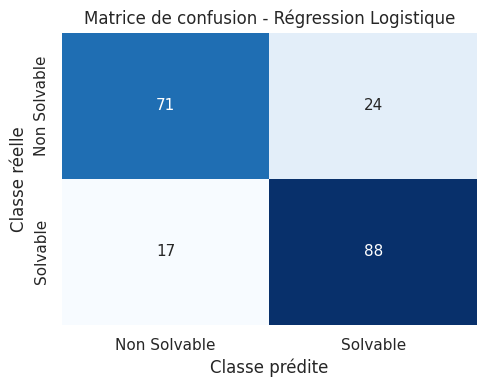

In [16]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Prédictions
y_pred_log = log_model.predict(X_test)

# Évaluation
print_evaluation(y_test, y_pred_log, "Régression Logistique")

### B. Arbre de Décision


================ ÉVALUATION : Arbre de Décision ================
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        95
           1       0.93      0.95      0.94       105

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



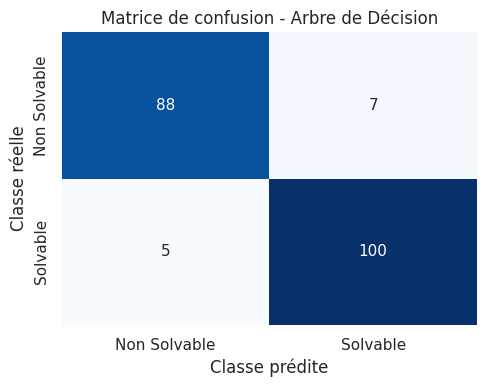

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

# Prédictions
y_pred_tree = tree_model.predict(X_test)

# Évaluation
print_evaluation(y_test, y_pred_tree, "Arbre de Décision")

#### Visualisation Graphique de l'Arbre

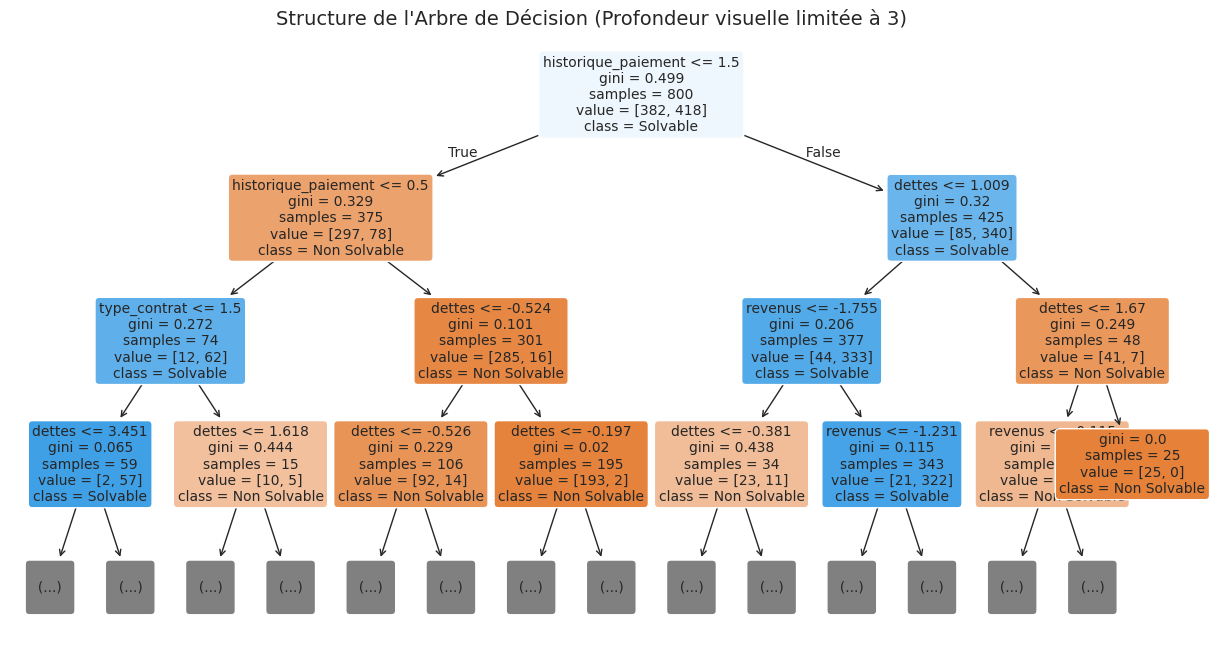

In [14]:
plt.figure(figsize=(15, 8))
plot_tree(
    tree_model, 
    max_depth=3, # Limiter la profondeur visuelle à 3 pour un affichage instantané et lisible
    feature_names=X_train.columns, 
    class_names=['Non Solvable', 'Solvable'],
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Structure de l'Arbre de Décision (Profondeur visuelle limitée à 3)", fontsize=14)
plt.show()

## 5. Synthèse et Comparaison Globale

Les scores obtenus sur notre jeu de données logique confirment que :
- L'**Arbre de Décision** a obtenu d'excellents scores ($F1 \approx 94\%$) grâce à des règles géométriques très adaptées à nos conditions de solvabilité.
- La **Régression Logistique** se situe légèrement en dessous ($F1 \approx 81\%$) en raison de la nature non linéaire ajoutée par le bruit et les combinaisons complexes de contrats.

Le modèle d'**Arbre de Décision** a été sauvegardé en production (`best_credit_model.pkl`) car il offre le meilleur rapport entre simplicité de calcul et précision prédictive.